# 산학프로젝트
**제조 공정 품질 불량 예측**

## import

In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
labeled=pd.read_csv('labeled_data.csv', encoding='utf-8')

In [4]:
labeled.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 데이터 전처리

In [5]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [6]:
info_df(labeled)

,Columns,Non-Null Count,Dtype
0,_id,7996,str
1,TimeStamp,7996,str
2,PART_FACT_PLAN_DATE,7996,str
3,PART_FACT_SERIAL,7996,int64
4,PART_NAME,7996,str
5,EQUIP_CD,7996,str
6,EQUIP_NAME,7996,str
7,PassOrFail,7996,str
8,Reason,71,str
9,Injection_Time,7996,float64


### 중복값 제거

In [7]:
labeled.duplicated().sum()

np.int64(2764)

In [8]:
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)
drop_dup.shape

(5232, 45)

In [9]:
drop_dup['PART_NAME'].value_counts()

PART_NAME
CN7 W/S SIDE MLD'G RH        1989
CN7 W/S SIDE MLD'G LH        1985
RG3 MOLD'G W/SHLD, LH         628
RG3 MOLD'G W/SHLD, RH         628
SP2 CVR ROOF RACK CTR, RH       1
JX1 W/S SIDE MLD'G RH           1
Name: count, dtype: int64

### CN7, RG3 제외 삭제

In [10]:
# CN7, RG3만 활용
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

In [11]:
drop_part.shape

(5230, 45)

### 불필요한 변수 삭제

In [12]:
drop_part.columns

Index(['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
       'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'PassOrFail', 'Reason',
       'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time',
       'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position',
       'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed',
       'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure',
       'Max_Switch_Over_Pressure', 'Max_Back_Pressure',
       'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2',
       'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5',
       'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature',
       'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3',
       'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6',
       'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9',
       'Mold_Temperature_10', 'Mold_Temperature_11', 

In [13]:
# 불필요한 컬럼 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

In [14]:
final_df.shape

(5230, 25)

In [15]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,Y,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,Y,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,Y,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,Y,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,Y,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


### PassOrFail 인코딩

In [16]:
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

### 데이터 분할

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(4184, 24) (4184,)
(1046, 24) (1046,)


### 데이터 스케일링

In [18]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## 모델링

### Base Model

#### Random Forest

In [19]:
from sklearn import set_config
set_config(display='text')

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=1000, random_state=0)

In [20]:
pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(rf_acc)

0.9818355640535373


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



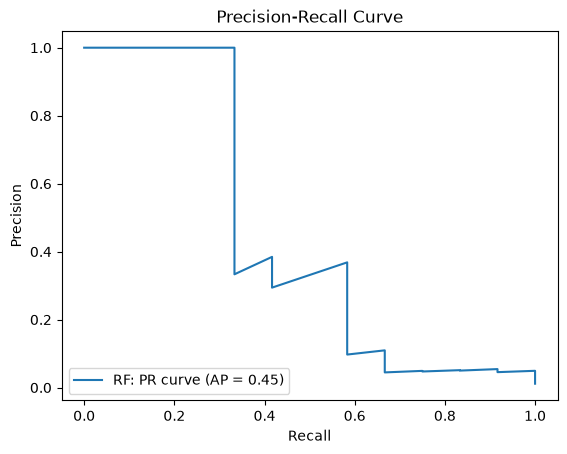

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
rf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob[:, 1])
ap_score = average_precision_score(y_test, rf_prob[:, 1])

import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, label=f'RF: PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

### 클래스 가중치

In [28]:
w_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1, random_state=0)
w_rf.fit(x_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=1000, n_jobs=1, random_state=0)

In [29]:
pred_wrf=w_rf.predict(x_test_scaled)
w_rf_acc=rf.score(x_test_scaled, y_test)
print(w_rf_acc)

0.9818355640535373


In [30]:
print(classification_report(y_test, pred_wrf, target_names=['양품', '불량']))

              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



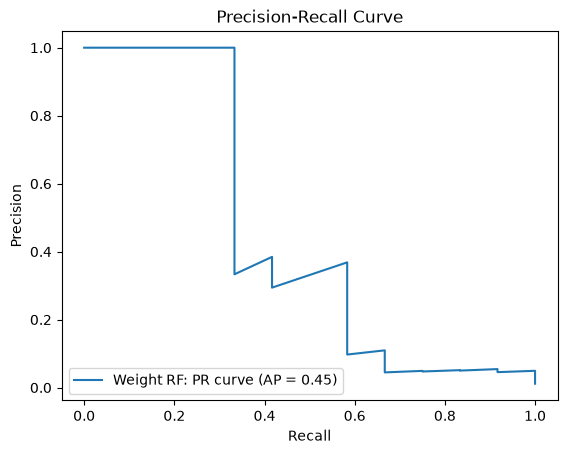

In [31]:
wrf_prob = rf.predict_proba(x_test_scaled)
precision, recall, thresholds = precision_recall_curve(y_test, wrf_prob[:, 1])
ap_score = average_precision_score(y_test, wrf_prob[:, 1])

import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, label=f'Weight RF: PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

### SMOTE: Sampling

In [32]:
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [33]:
# 학습데이터에 SMOTE 적용
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(8272, 24) (8272,)


In [34]:
x_train_smote[:5]

array([[ 0.57952796,  0.60644569,  0.52738193, -0.52167709,  0.54474781,
        -0.50994252,  0.59299723,  0.57103517, -0.57798195,  0.44896415,
         0.85948431,  0.00222524,  0.62207941, -0.49720396,  0.02837096,
        -0.530315  , -0.34370475, -0.48078644, -0.0769271 , -0.5576974 ,
        -0.72827301, -0.41907038, -0.63274298, -0.58366175],
       [ 0.55213645,  0.54011872,  0.66861983, -0.60138796,  0.61205668,
        -0.59269444,  0.57574077,  0.57103517, -0.54260724,  0.44896415,
         0.86025568, -0.2322233 ,  0.54101033, -0.50977371, -0.07071494,
        -0.50905482, -0.49590621, -0.61068817, -0.79476815, -0.46731914,
        -0.63630161,  0.83169162,  0.13041552, -0.16182014],
       [ 0.57404955,  0.59981286,  0.53915194, -0.52167709,  0.54474781,
        -0.53752649,  0.59299723,  0.57103517, -0.57476611, -0.89664884,
         0.85948431,  0.00222524,  0.62207941, -0.50977371, -0.00465725,
        -0.42402056, -0.4741622 , -0.50243783,  0.10253316, -0.53510197,
  

In [35]:
# 학습 모델 저장
model_dict={}

#### Random Forest

In [36]:
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

#### Bagging

In [37]:
from sklearn.ensemble import BaggingClassifier

smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging']=smote_bag

#### XGBoost

In [38]:
from xgboost import XGBClassifier

smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost']=smote_xgb

In [39]:
# 저장된 모델 확인
model_dict

{'RandomForest': RandomForestClassifier(n_estimators=1000, random_state=0),
 'Bagging': BaggingClassifier(n_estimators=1000, random_state=0),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1000,
               n_jobs=None, num_parallel_tree=None, ...)}

#### Predict

RandomForest
Accuracy: 0.9818355640535373
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046

Bagging
Accuracy: 0.9799235181644359
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.58      0.40        12

    accuracy                           0.98      1046
   macro avg       0.65      0.78      0.69      1046
weighted avg       0.99      0.98      0.98      1046

XGBoost
Accuracy: 0.9837476099426387
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12



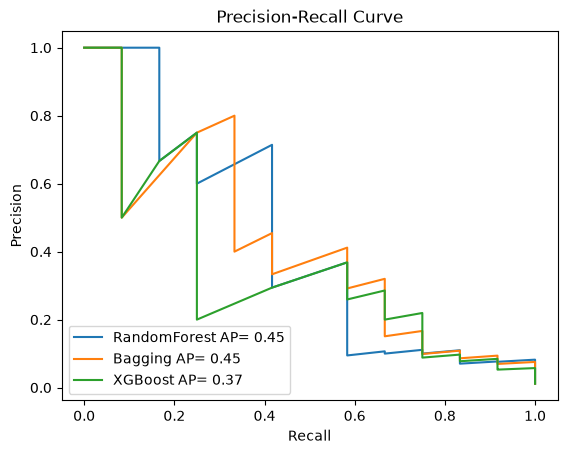

In [40]:
# 저장한 학습 모델 불러와서 예측
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))

    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

#### SMOTE 파라미터 조정

In [41]:
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(4549, 24) (4549,)


In [42]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost']=smote_xgb

# 저장된 모델 확인
model_dict

{'RandomForest': RandomForestClassifier(n_estimators=1000, random_state=0),
 'Bagging': BaggingClassifier(n_estimators=1000, random_state=0),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1000,
               n_jobs=None, num_parallel_tree=None, ...)}

RandomForest
Accuracy: 0.9837476099426387
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

Bagging
Accuracy: 0.9837476099426387
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost
Accuracy: 0.9837476099426387
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12



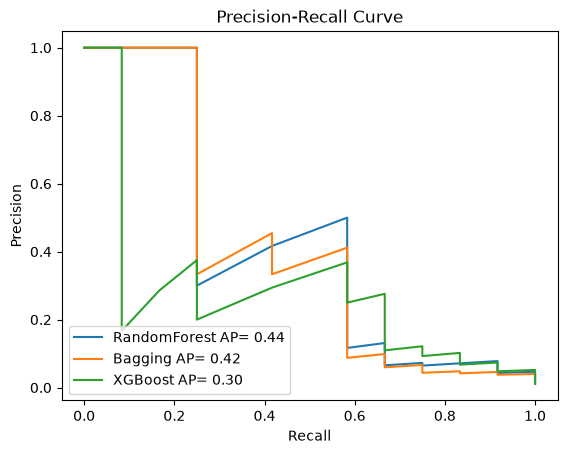

In [43]:
# 저장한 학습 모델 불러와서 예측
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))

    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

### 제품명 변수 추가

In [12]:
drop_part.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
drop_part['Part']=drop_part['PART_NAME'].str[:3]

drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10',
              'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5',
              'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 
              'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'Reason', 'Switch_Over_Position', 'PART_NAME',
              'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

In [23]:
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

In [26]:
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(4184, 25) (4184,)
(1046, 25) (1046,)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [30]:
from sklearn import set_config
set_config(display='text')

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=1000, random_state=0)

In [31]:
pred_rf=rf.predict(x_test_scaled)
rf_acc=rf.score(x_test_scaled, y_test)
print(rf_acc)

0.9818355640535373


In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_rf, target_names=['양품', '불량']))

              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046

